wandb: Currently logged in as: dominik-babiarczyk1 (dominik-babiarczyk1-agh). Use `wandb login --relogin` to force relogin


100.0%


Extracting ../fashion-mnist/data\FashionMNIST\raw\train-images-idx3-ubyte.gz to ../fashion-mnist/data\FashionMNIST\raw



100.0%


Extracting ../fashion-mnist/data\FashionMNIST\raw\train-labels-idx1-ubyte.gz to ../fashion-mnist/data\FashionMNIST\raw



100.0%


Extracting ../fashion-mnist/data\FashionMNIST\raw\t10k-images-idx3-ubyte.gz to ../fashion-mnist/data\FashionMNIST\raw



100.0%


Extracting ../fashion-mnist/data\FashionMNIST\raw\t10k-labels-idx1-ubyte.gz to ../fashion-mnist/data\FashionMNIST\raw



wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.


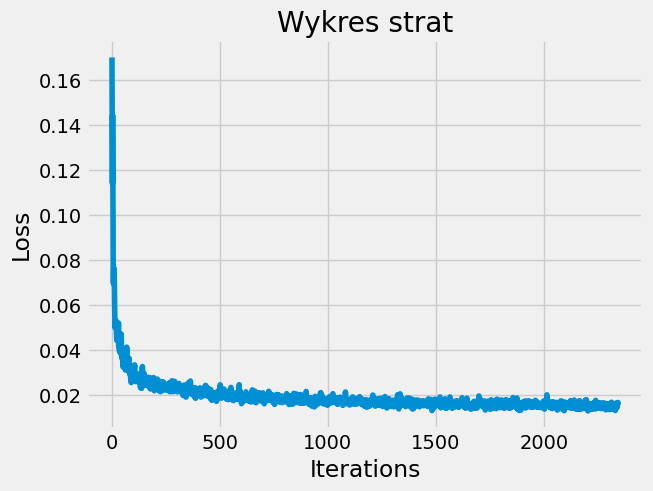

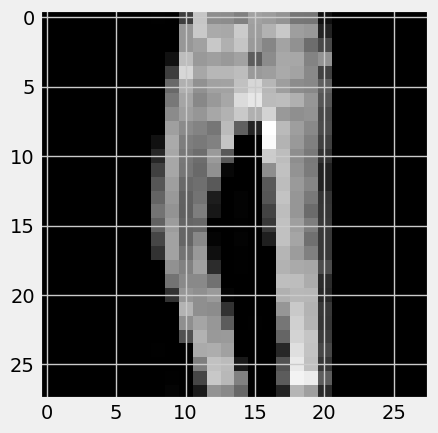

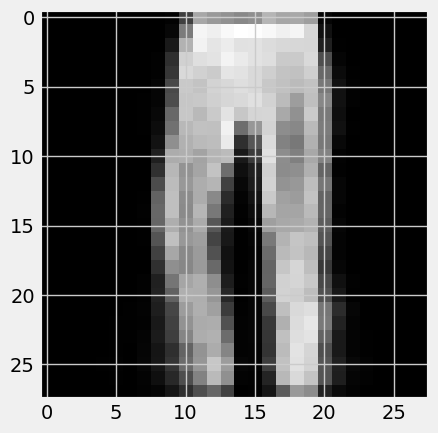

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# 1. Przygotowanie danych
# transform = transforms.Compose([
#     transforms.ToTensor(),  # Przekształcenie obrazów na tensory
#     transforms.Normalize((0.5,), (0.5,))  # Normalizacja do zakresu [-1, 1]
# ])

import wandb
wandb.login()

# Start a new W&B run



tensor_transform = transforms.ToTensor()

# Pobranie danych MNIST
train_dataset = datasets.FashionMNIST(root='../fashion-mnist/data', train=True, transform=tensor_transform, download=True)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)


# 2. Definicja modelu
class NeuralNetwork(nn.Module):
    def __init__(self):
        super(NeuralNetwork, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(28 * 28, 512),  # Warstwa ukryta
            nn.ReLU(),
            nn.Linear(512, 10)  # Warstwa wyjściowa
        )
        
        self.decoder = nn.Sequential(
            nn.Linear(10, 512), nn.ReLU(),
            nn.Linear(512, 28 * 28), nn.Sigmoid(),
        )
        
    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded
    

model = NeuralNetwork()

lr = 0.001
epochs = 5

run = wandb.init(
    project="my-awesome-project",  # Set the project where this run will be logged
    config={  # Track hyperparameters and run metadata
        "learning_rate": 0.01,
        "epochs": 10,
    },
)

# 3. Konfiguracja procesu uczenia
criterion = nn.MSELoss()  # Funkcja straty
optimizer = optim.RMSprop(model.parameters(), lr=lr)  # Optymalizator RMSprop



outputs = []
losses = []

for epoch in range(epochs):
    for image,_ in train_loader:
        
        image = image.reshape(-1, 28 * 28)
        
        reconstruction = model(image)
        
        loss = criterion(reconstruction, image)
        
        optimizer.zero_grad()  # Wyzerowanie gradientów
        loss.backward()  # Backpropagation
        optimizer.step()  # Aktualizacja wag
        wandb.log({ "loss": loss})
        
        losses.append(loss.item())
    outputs.append((epoch, image, reconstruction))    
    
    
plt.style.use('fivethirtyeight')
plt.xlabel('Iterations')
plt.ylabel('Loss')
 
# Plotting the last 100 values
plt.plot(losses)
plt.title("Wykres strat")
plt.show()


for i, item in enumerate(image[:1]):
    plt.figure() 
  # Reshape the array for plotting
    item = item.reshape(28, 28)
    plt.imshow(item.detach().numpy(), cmap="gray")  # Konwersja do NumPy
 
for i, item in enumerate(reconstruction[:1]):  # Ograniczenie do 5 obrazów
    plt.figure()
    item = item.detach().numpy().reshape(28, 28)  # Detach i reshape
    plt.imshow(item, cmap="gray")


C:\semestr7\MachineLearningV2\lab1\pythonProject\.venv\Lib\site-packages\torch\_tensor.py:955: UserWarning: non-inplace resize is deprecated
  warnings.warn("non-inplace resize is deprecated")


<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>


C:\Users\domin\AppData\Local\Temp\ipykernel_23424\3540989096.py:3: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure()


<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>


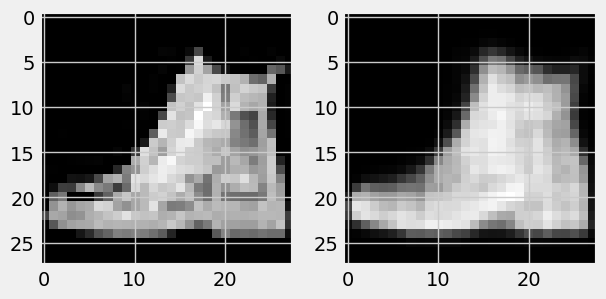

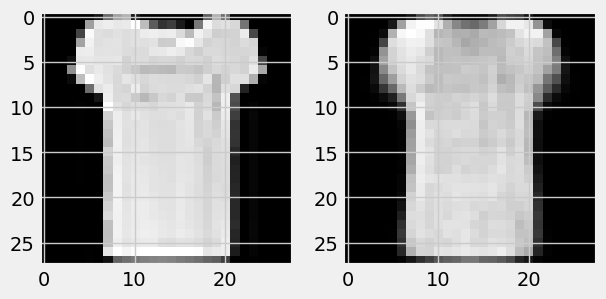

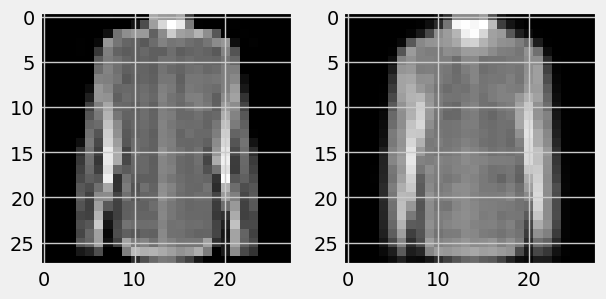

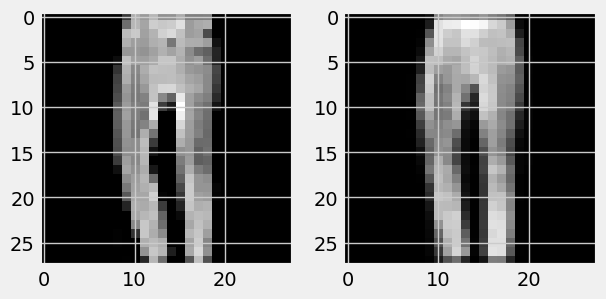

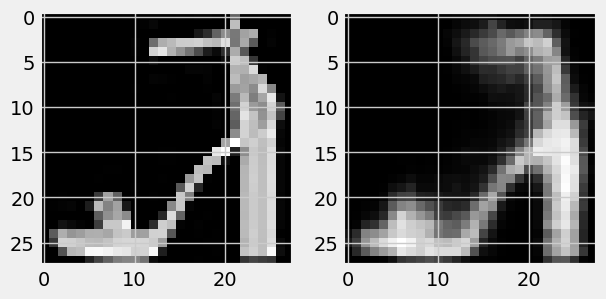

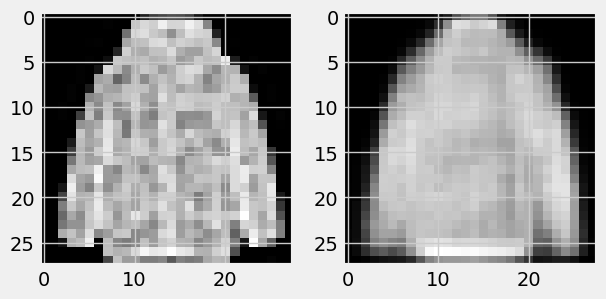

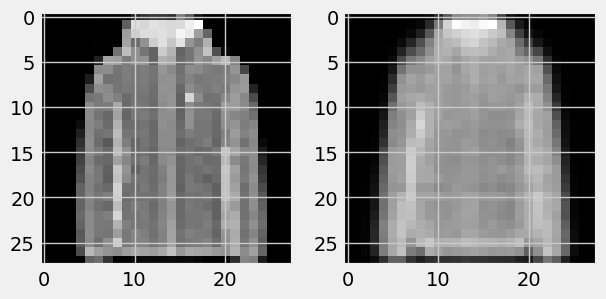

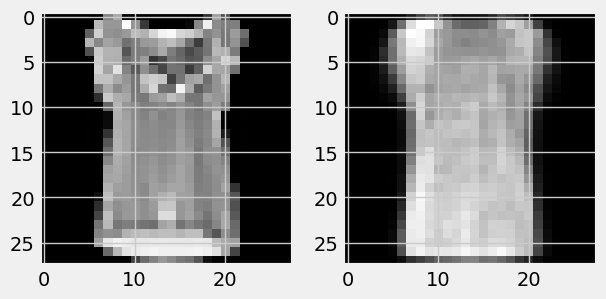

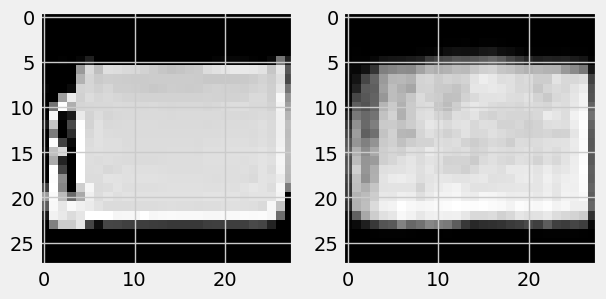

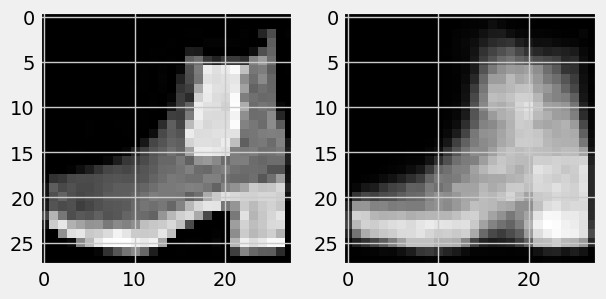

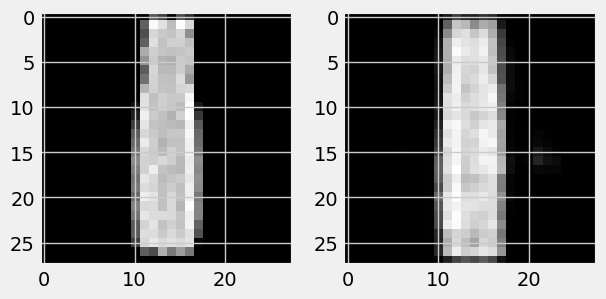

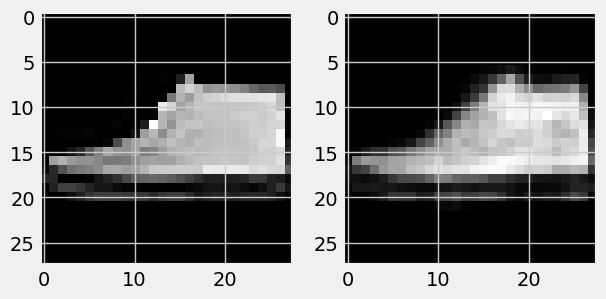

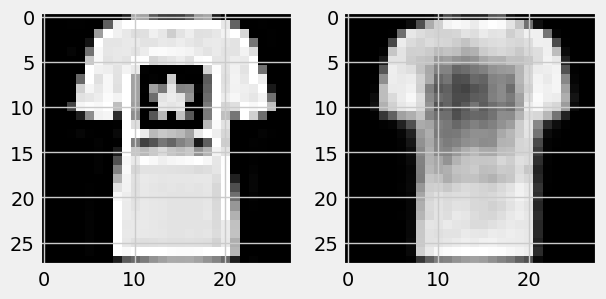

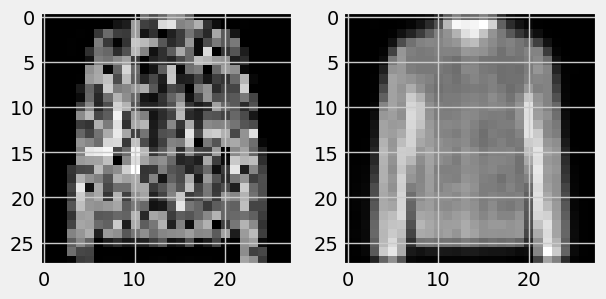

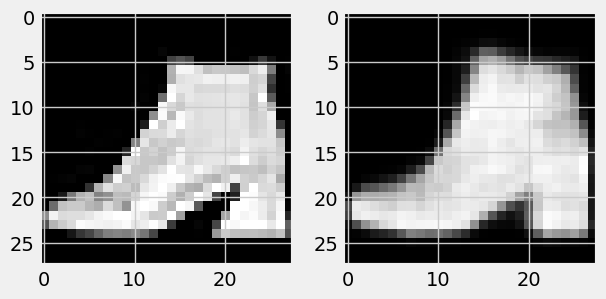

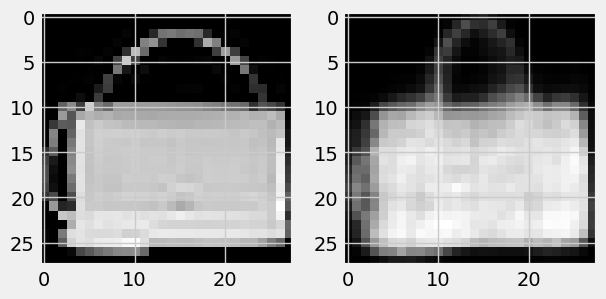

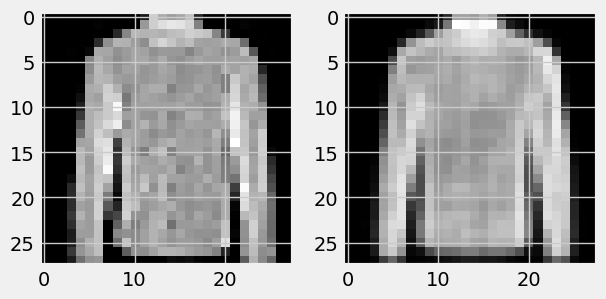

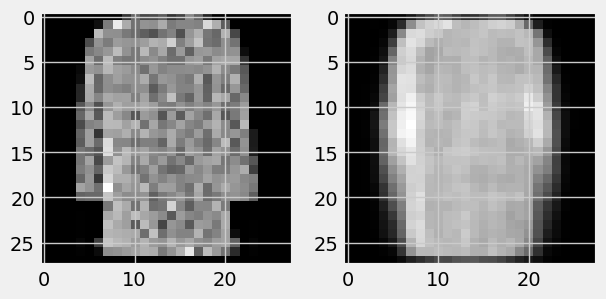

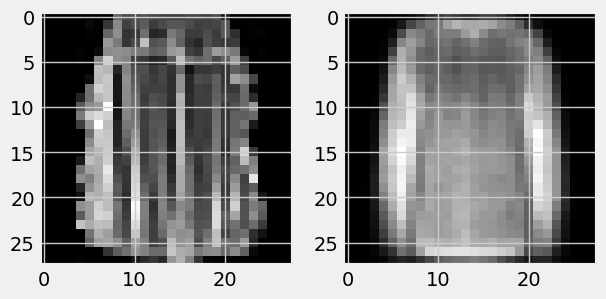

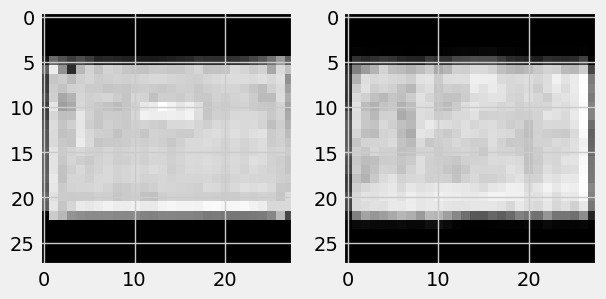

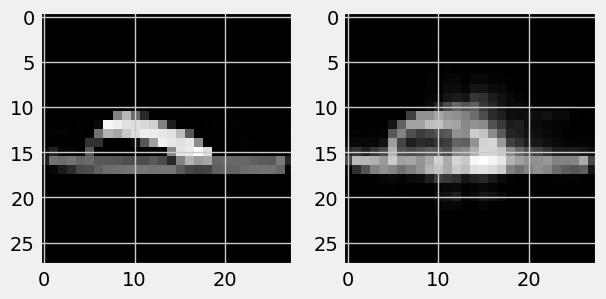

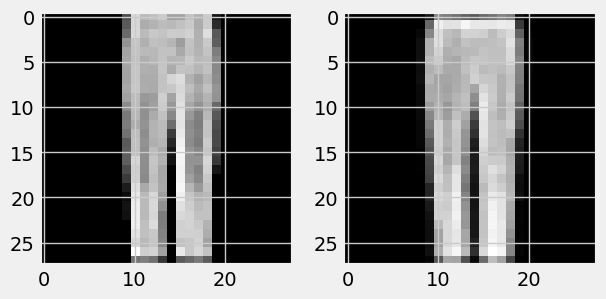

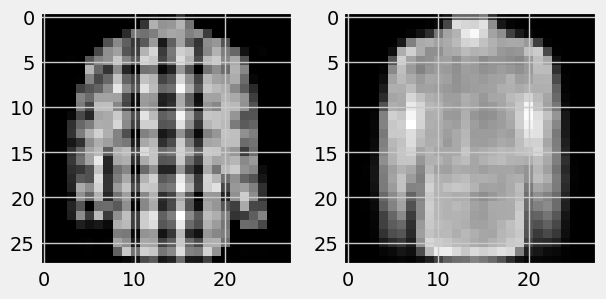

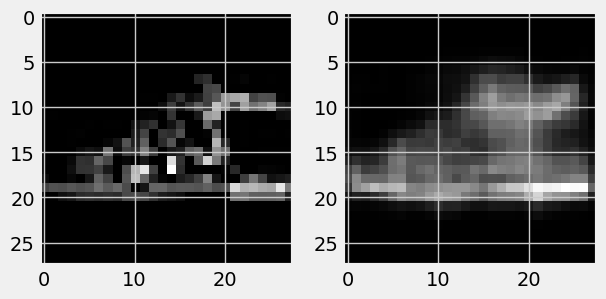

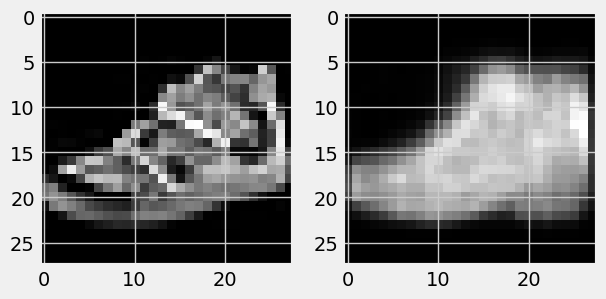

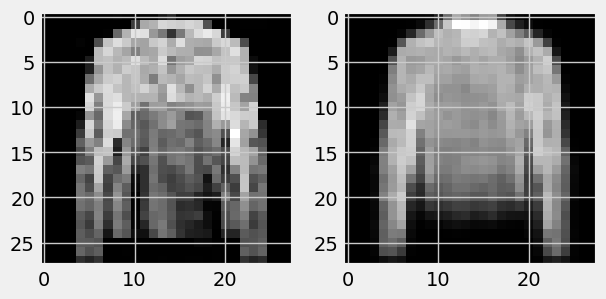

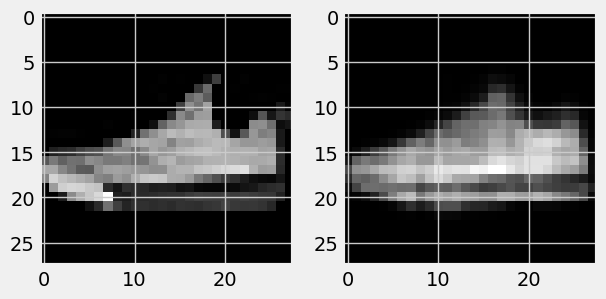

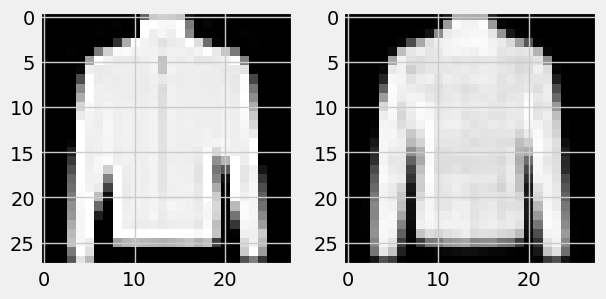

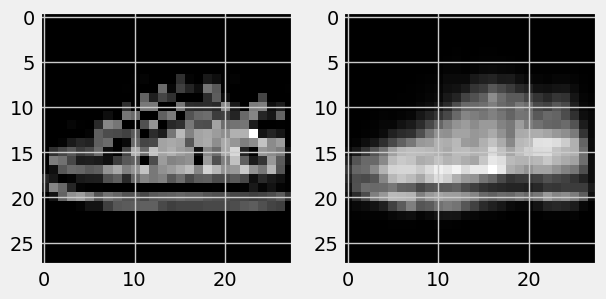

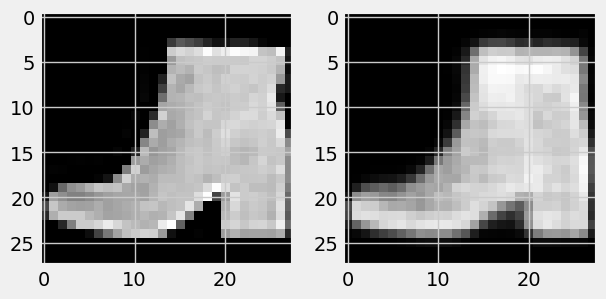

In [2]:
for i in range(30):
    tensor1 = outputs[0][1][i]
    plt.figure()
    plt.subplot(1, 2, 1)
    plt.imshow(tensor1.resize(28,28), cmap="gray")
    plt.subplot(1, 2, 2)
    tensor = model(tensor1).detach()
    plt.imshow(tensor.resize(28,28), cmap="gray")
    print(type(outputs[0][2]))